# Tokenization Papers

In [1]:
import paper_dataset
import pandas as pd
import importlib
import re
import matplotlib.pyplot as plt
importlib.reload(paper_dataset)

<module 'paper_dataset' from '/lnet/work/people/vico/TokSurvey/paper_dataset.py'>

In [2]:
df = paper_dataset.load()

## Samples and RE 

In [ ]:
samples = paper_dataset.sample(df, 5)
for s in samples.iloc:
    paper_dataset.print_sample(s)

Title: The Geometry of Numerical Reasoning: Language Models Compare Numeric Properties in Linear Subspaces
Author(s): El-Shangiti, Ahmed Oumar and Hiraoka, Tatsuya and AlQuabeh, Hilal and Heinzerling, Benjamin and Inui, Kentaro
Year: 2025
Venue: None (ACL)
Volume: Proceedings of the 2025 Conference of the Nations of the Americas Chapter of the Association for Computational Linguistics: Human Language Technologies (Volume 2: Short Papers)
--------------------------------------------------------------------------------
Abstract:
   This paper investigates whether large language models (LLMs) utilize
   numerical attributes encoded in a low-dimensional subspace of
   theembedding space when answering questions involving numeric
   comparisons, e.g., Was Cristiano born before Messi? We first
   identified,using partial least squares regression, these subspaces,
   which effectively encode the numerical attributes associated with the
   entities in comparison prompts. Further, we demonstrat

In [3]:
recent = df[df['year'] >= 2016]
keywords = re.compile(r"token|sub-?word|segment")
tokenization = recent[recent["abstract"].apply(lambda x: x is not None and re.search(keywords, x.lower()) is not None)]

print(f"Number of papers in the dataset: {len(df)}")
print(f"Number of papers since 2016: {len(recent)}")
print(f"Number of papers on tokenization since 2016: {len(tokenization)}")

Number of papers in the dataset: 149355
Number of papers since 2016: 101891
Number of papers on tokenization since 2016: 8266


In [ ]:
samples = paper_dataset.sample(tokenization, 3)
for s in samples.iloc:
    paper_dataset.print_sample(s)

Title: Spike-driven Transformer V2: Meta Spiking Neural Network Architecture Inspiring the Design of Next-generation Neuromorphic Chips
Author(s): Man Yao and JiaKui Hu and Tianxiang Hu and Yifan Xu and Zhaokun Zhou and Yonghong Tian and Bo XU and Guoqi Li
Year: 2024
Venue: ICLR 2024 poster (ICLR)
Volume: The Twelfth International Conference on Learning Representations
--------------------------------------------------------------------------------
Abstract:
   Neuromorphic computing, which exploits Spiking Neural Networks (SNNs) on
   neuromorphic chips, is a promising energy-efficient alternative to
   traditional AI. CNN-based SNNs are the current mainstream of
   neuromorphic computing. By contrast, no neuromorphic chips are designed
   especially for Transformer-based SNNs, which have just emerged, and
   their performance is only on par with CNN-based SNNs, offering no
   distinct advantage. In this work, we propose a general Transformer-based
   SNN architecture, termed as ``Met

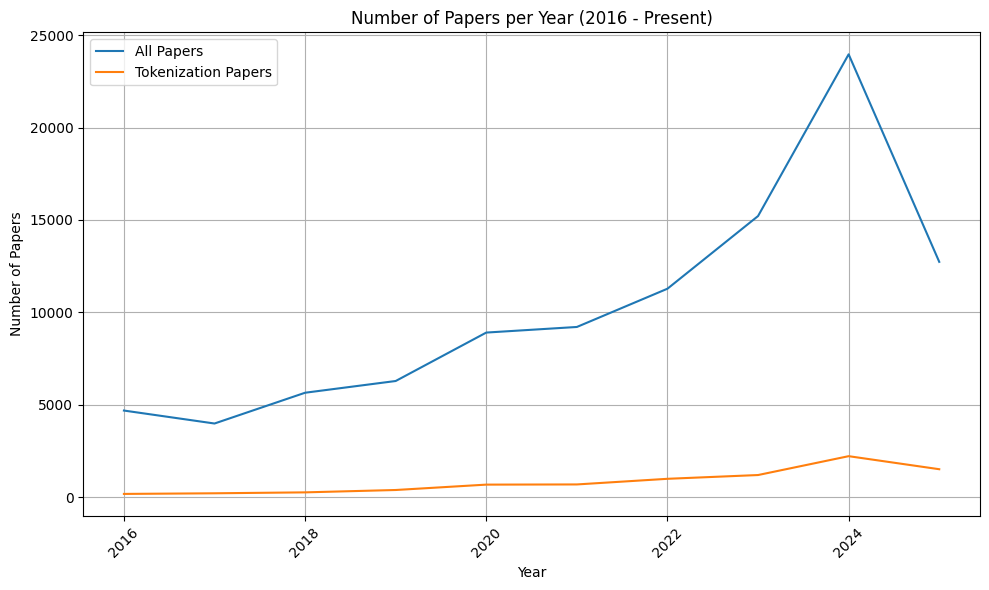

In [6]:
# Plot the number of papers per year
plt.figure(figsize=(10, 6))
recent_counts = recent['year'].value_counts().sort_index()
recent_counts.plot(kind="line")
tokenization_counts = tokenization['year'].value_counts().sort_index()
tokenization_counts.plot(kind="line")
plt.title('Number of Papers per Year (2016 - Present)')
plt.xlabel('Year')
plt.ylabel('Number of Papers')
plt.xticks(rotation=45)
plt.legend(['All Papers', 'Tokenization Papers'])
plt.grid(True)
plt.tight_layout()
plt.show()

## Filter with LLM and save the results

In [12]:
import tqdm
import llm_filter
import paper_dataset
import importlib
import matplotlib.pyplot as plt
import re
tqdm.tqdm.pandas()

In [ ]:
# abstracts = tokenization['abstract'].tolist()
# titles = tokenization['title'].tolist()

# tokenization['topic'] = llm_filter.filter_topic(titles, abstracts)
# Merge the tokenization DataFrame with the original DataFrame adding the column 'topic' (bool)
# df = df.merge(tokenization[['bibtex_id', 'topic']], on='bibtex_id', how='left')
# Save df to jsonl file
# df.to_json('topic_papers_retry_ta_2shot.jsonl', orient='records', lines=True)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8266/8266 [1:01:39<00:00,  2.23it/s]
/COMP.TMP/vico_5779059/ipykernel_3487670/4142716666.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tokenization['topic'] = tokenization.progress_apply(lambda x: llm_filter.filter_topic(x['abstract'], x['title']), axis=1)


In [6]:
df = paper_dataset.load('data/topic_papers.jsonl')
recent = df[df['year'] >= 2016]
real_tokenization = df[df['topic'] == True]

In [7]:
samples = paper_dataset.sample(real_tokenization, 3)
for s in samples.iloc:
    paper_dataset.print_sample(s)

Title: {M}orfessor-enriched features and multilingual training for canonical morphological segmentation
Author(s): Rouhe, Aku and Gr{\"o}nroos, Stig-Arne and Virpioja, Sami and Creutz, Mathias and Kurimo, Mikko
Year: 2022
Venue: None (ACL)
Volume: Proceedings of the 19th SIGMORPHON Workshop on Computational Research in Phonetics, Phonology, and Morphology
--------------------------------------------------------------------------------
Abstract:
   In our submission to the SIGMORPHON 2022 Shared Task on Morpheme
   Segmentation, we study whether an unsupervised morphological
   segmentation method, Morfessor, can help in a supervised setting.
   Previous research has shown the effectiveness of the approach in
   semisupervised settings with small amounts of labeled data. The current
   tasks vary in data size: the amount of word-level annotated training
   data is much larger, but the amount of sentencelevel annotated training
   data remains small. Our approach is to pre-segment the in

In [13]:
recent = paper_dataset.load()
recent = recent[recent['year'] >= 2016]
keywords = re.compile(r"token|sub-?word|segment")
possible = recent[recent["abstract"].progress_apply(lambda x: x is not None and re.search(keywords, x.lower()) is not None)]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 101891/101891 [00:01<00:00, 97636.93it/s]


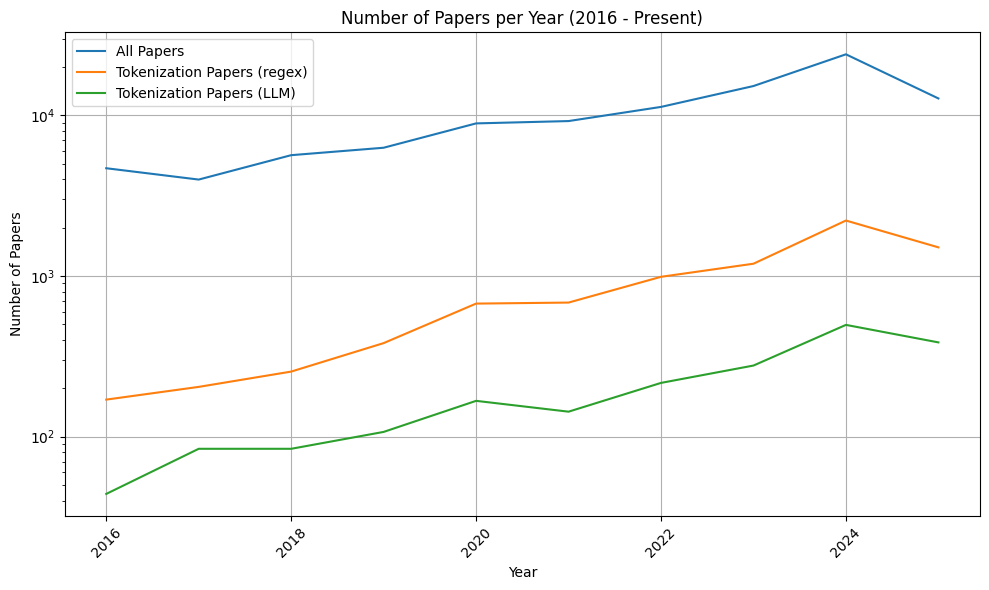

In [14]:
# Plot the number of papers per year
plt.figure(figsize=(10, 6))
recent_counts = recent['year'].value_counts().sort_index()
recent_counts.plot(kind="line", logy=True)
tokenization_counts = possible['year'].value_counts().sort_index()
tokenization_counts.plot(kind="line", logy=True)
real_tokenization_counts = real_tokenization['year'].value_counts().sort_index()
real_tokenization_counts.plot(kind="line", logy=True)
plt.title('Number of Papers per Year (2016 - Present)')
plt.xlabel('Year')
plt.ylabel('Number of Papers')
plt.xticks(rotation=45)
plt.legend(['All Papers', 'Tokenization Papers (regex)', 'Tokenization Papers (LLM)'])
plt.grid(True)
plt.tight_layout()
plt.show()

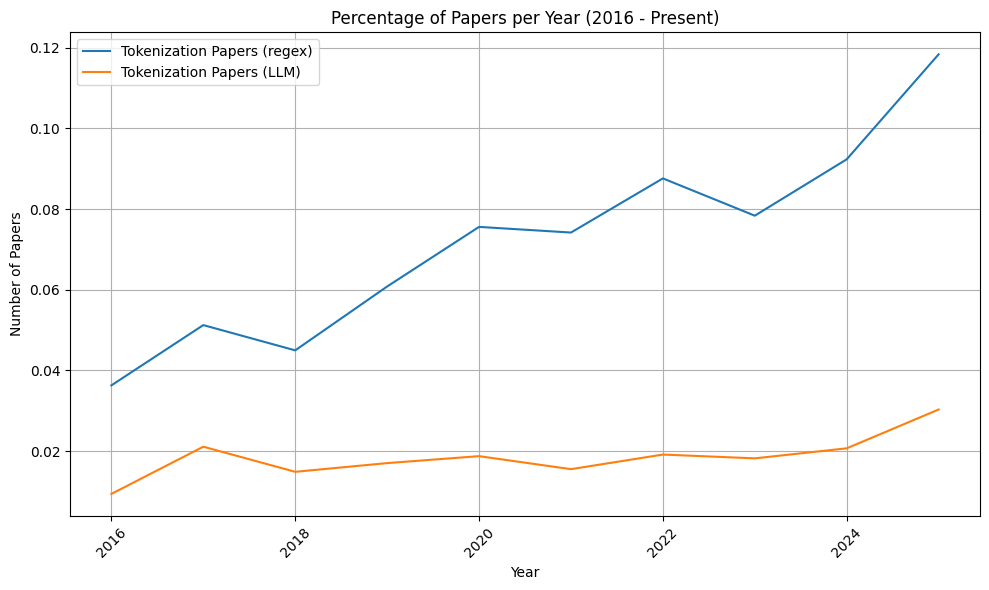

In [15]:
# Plot the number of papers per year
plt.figure(figsize=(10, 6))
recent_counts = recent['year'].value_counts().sort_index()
tokenization_counts = possible['year'].value_counts().sort_index()
(tokenization_counts / recent_counts).plot(kind="line")
real_tokenization_counts = real_tokenization['year'].value_counts().sort_index()
(real_tokenization_counts / recent_counts).plot(kind="line")
plt.title('Percentage of Papers per Year (2016 - Present)')
plt.xlabel('Year')
plt.ylabel('Number of Papers')
plt.xticks(rotation=45)
plt.legend(['Tokenization Papers (regex)', 'Tokenization Papers (LLM)'])
plt.grid(True)
plt.tight_layout()
plt.show()

## Type of the paper
- Tokeniser/Evaluation/Application/Other

In [16]:
import tqdm
import llm_filter
import paper_dataset
import importlib
import matplotlib.pyplot as plt
import re
tqdm.tqdm.pandas()

In [74]:
importlib.reload(llm_filter)

<module 'llm_filter' from '/lnet/work/people/vico/TokSurvey/llm_filter.py'>

In [ ]:
df = paper_dataset.load('data/topic_papers.jsonl')
real_tokenization = df[df['topic'] == True]
real_tokenization.shape

(2004, 14)

In [75]:
llm_filter.test('test_set.json', lambda a, t, c: llm_filter.is_tokeniser(a, t), 'tokenization')
llm_filter.test('test_set.json', lambda a, t, c: llm_filter.is_evaluation(a, t), 'evaluation')
llm_filter.test('test_set.json', lambda a, t, c: llm_filter.is_survey(a, t), 'survey')

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:27<00:00,  3.10s/it]


Title: ADASPLASH: Adaptive Sparse Flash Attention
Answer: False (Reference: None)
--------------------------------------------------------------------------------
Title: Subword Regularization: Improving Neural Network Translation Models with Multiple Subword Candidates
Answer: True (Reference: True)
--------------------------------------------------------------------------------
Title: LANGUAGE MODELLING WITH PIXELS
Answer: True (Reference: True)
--------------------------------------------------------------------------------
Title: Dynamic Chunking for End-to-End Hierarchical Sequence Modeling
Answer: True (Reference: True)
--------------------------------------------------------------------------------
Title: Tokenization and the Noiseless Channel
Answer: False (Reference: False)
--------------------------------------------------------------------------------
Title: Do All Languages Cost the Same? Tokenization in the Era of Commercial Language Models
Answer: False (Reference: False)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:25<00:00,  2.84s/it]


Title: ADASPLASH: Adaptive Sparse Flash Attention
Answer: False (Reference: None)
--------------------------------------------------------------------------------
Title: Subword Regularization: Improving Neural Network Translation Models with Multiple Subword Candidates
Answer: False (Reference: False)
--------------------------------------------------------------------------------
Title: LANGUAGE MODELLING WITH PIXELS
Answer: False (Reference: False)
--------------------------------------------------------------------------------
Title: Dynamic Chunking for End-to-End Hierarchical Sequence Modeling
Answer: False (Reference: False)
--------------------------------------------------------------------------------
Title: Tokenization and the Noiseless Channel
Answer: True (Reference: True)
--------------------------------------------------------------------------------
Title: Do All Languages Cost the Same? Tokenization in the Era of Commercial Language Models
Answer: True (Reference: Tru

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:25<00:00,  2.85s/it]

Title: ADASPLASH: Adaptive Sparse Flash Attention
Answer: False (Reference: None)
--------------------------------------------------------------------------------
Title: Subword Regularization: Improving Neural Network Translation Models with Multiple Subword Candidates
Answer: False (Reference: False)
--------------------------------------------------------------------------------
Title: LANGUAGE MODELLING WITH PIXELS
Answer: False (Reference: False)
--------------------------------------------------------------------------------
Title: Dynamic Chunking for End-to-End Hierarchical Sequence Modeling
Answer: False (Reference: False)
--------------------------------------------------------------------------------
Title: Tokenization and the Noiseless Channel
Answer: False (Reference: False)
--------------------------------------------------------------------------------
Title: Do All Languages Cost the Same? Tokenization in the Era of Commercial Language Models
Answer: False (Reference: 

In [83]:
real_tokenization = real_tokenization.copy()

real_tokenization['tokenization'] = real_tokenization.progress_apply(lambda x: llm_filter.is_tokeniser(x['title'], x['abstract']), axis=1)
real_tokenization['evaluation'] = real_tokenization.progress_apply(lambda x: llm_filter.is_evaluation(x['title'], x['abstract']), axis=1)
real_tokenization['survey'] = real_tokenization.progress_apply(lambda x: llm_filter.is_survey(x['title'], x['abstract']), axis=1)
real_tokenization['application'] = ~(real_tokenization['tokenization'] | real_tokenization['evaluation'] | real_tokenization['survey'])

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2004/2004 [09:30<00:00,  3.51it/s]


In [92]:
df = paper_dataset.load('data/topic_papers.jsonl')
df = df.merge(real_tokenization[['bibtex_id', 'tokenization', 'evaluation', 'application', 'survey']], on='bibtex_id', how='left')
df.to_json('data/papers_with_category.jsonl', orient='records', lines=True)

In [94]:
print("§" * 60)
print("TOKENIZATION")
print("§" * 60)

tmp = df[df['tokenization'] == True]
samples = paper_dataset.sample(tmp, 3)
for s in samples.iloc:
    paper_dataset.print_sample(s)

§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§
TOKENIZATION
§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§
Title: Plongements lexicaux sp{\'e}cifiques {\`a} la langue arabe : application {\`a} l{'}analyse d{'}opinions ({A}rabic-specific embedddings : application in Sentiment Analysis)
Author(s): Barhoumi, Amira and Camelin, Nathalie and Aloulou, Chafik and Est{\`e}ve, Yannick and Hadrich Belguith, Lamia
Year: 2019
Venue: None (ACL)
Volume: Actes de la Conf{\'e}rence sur le Traitement Automatique des Langues Naturelles (TALN) PFIA 2019. Volume II : Articles courts
--------------------------------------------------------------------------------
Abstract:
   Nous nous int{\'e}ressons, dans cet article, {\`a} la t{\^a}che
   d{'}analyse d{'}opinions en arabe. Nous {\'e}tudions la
   sp{\'e}cificit{\'e} de la langue arabe pour la d{\'e}tection de
   polarit{\'e}. Nous nous focalisons ici sur les caract{\'e}ristiques
   d{'}agglutination et de richesse morphologiq

In [95]:
print("§" * 60)
print("APPLICATION")
print("§" * 60)

tmp = df[df['application'] == True]
samples = paper_dataset.sample(tmp, 3)
for s in samples.iloc:
    paper_dataset.print_sample(s)

§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§
APPLICATION
§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§
Title: Mitigate Extrinsic Social Bias in Pre-trained Language Models via Continuous Prompts Adjustment
Author(s): Dai, Yiwei and Gu, Hengrui and Wang, Ying and Wang, Xin
Year: 2024
Venue: None (ACL)
Volume: Proceedings of the 2024 Conference on Empirical Methods in Natural Language Processing
--------------------------------------------------------------------------------
Abstract:
   Although pre-trained language models (PLMs) have been widely used in
   natural language understandings (NLU), they are still exposed to
   fairness issues. Most existing extrinsic debiasing methods rely on
   manually curated word lists for each sensitive groups to modify training
   data or to add regular constraints. However, these word lists are often
   limited by length and scope, resulting in the degradation performance of
   extrinsic bias mitigation. To address the

In [96]:
print("§" * 60)
print("EVALUATION")
print("§" * 60)

tmp = df[df['evaluation'] == True]
samples = paper_dataset.sample(tmp, 3)
for s in samples.iloc:
    paper_dataset.print_sample(s)


§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§
EVALUATION
§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§
Title: Analyzing Cognitive Plausibility of Subword Tokenization
Author(s): Beinborn, Lisa and Pinter, Yuval
Year: 2023
Venue: None (ACL)
Volume: Proceedings of the 2023 Conference on Empirical Methods in Natural Language Processing
--------------------------------------------------------------------------------
Abstract:
   Subword tokenization has become the de-facto standard for tokenization
   although comparative evaluations of their quality across languages are
   scarce. Existing evaluation studies focus on the effect of a
   tokenization algorithm on the performance in downstream tasks, or on
   engineering criteria such as the compression rate. We present a new
   evaluation paradigm that focuses on the cognitive plausibility of
   subword tokenization. We analyze the correlation of the tokenizer output
   with the reading time and accuracy of hum

In [97]:
print("§" * 60)
print("SURVEY")
print("§" * 60)

tmp = df[df['survey'] == True]
samples = paper_dataset.sample(tmp, 3)
for s in samples.iloc:
    paper_dataset.print_sample(s)

§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§
SURVEY
§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§
Title: An Assessment of Word Separation Practices in {O}ld {I}rish Text Resources and a Universal Method for Tokenising {O}ld {I}rish Text
Author(s): Doyle, Adrian and McCrae, John P.
Year: 2025
Venue: None (ACL)
Volume: Proceedings of the 5th Celtic Language Technology Workshop
--------------------------------------------------------------------------------
Abstract:
   The quantity of Old Irish text which survives in contemporary
   manuscripts is relatively small by comparison to what is available for
   well-resourced modern languages. Moreover, as it is a historical
   language, no more text will ever be generated by native speakers of Old
   Irish. This makes the text which has survived particularly valuable, and
   ideally, all of it would be annotated using a single, common annotation
   standard, thereby ensuring compatibility between text resources.

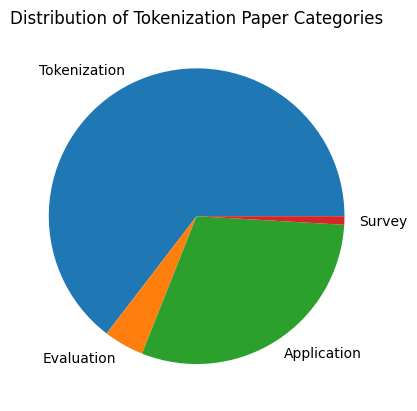

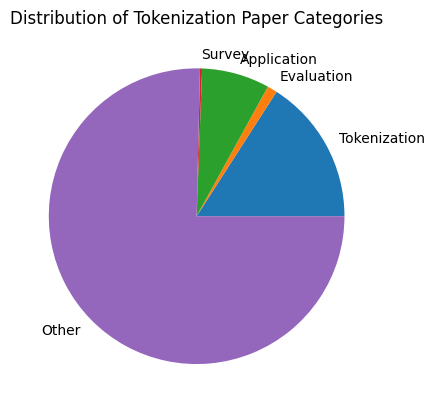

In [98]:
category_counts = {
    'Tokenization': real_tokenization['tokenization'].sum(),
    'Evaluation': real_tokenization['evaluation'].sum(),
    'Application': real_tokenization['application'].sum(),
    'Survey': real_tokenization['survey'].sum()
}
plt.figure()
plt.pie(category_counts.values(), labels=category_counts.keys())
plt.title('Distribution of Tokenization Paper Categories')
plt.show()

category_counts['Other'] = (df['topic'] == False).sum()
plt.figure()
plt.pie(category_counts.values(), labels=category_counts.keys())
plt.title('Distribution of Tokenization Paper Categories')
plt.show()

In [99]:
for i,j in category_counts.items():
    print(f"{i}: {j}")

Tokenization: 1322
Evaluation: 90
Application: 616
Survey: 19
Other: 6262


In [107]:
print("tokenization=True, evaluation=True, survey=True:", real_tokenization[(real_tokenization['tokenization'] == True) & (real_tokenization['evaluation'] == True) & (real_tokenization['survey'] == True)].shape[0])
print("tokenization=True, evaluation=True, survey=False:", real_tokenization[(real_tokenization['tokenization'] == True) & (real_tokenization['evaluation'] == True) & (real_tokenization['survey'] == False)].shape[0])
print("tokenization=True, evaluation=False, survey=True:", real_tokenization[(real_tokenization['tokenization'] == True) & (real_tokenization['evaluation'] == False) & (real_tokenization['survey'] == True)].shape[0])
print("tokenization=True, evaluation=False, survey=False:", real_tokenization[(real_tokenization['tokenization'] == True) & (real_tokenization['evaluation'] == False) & (real_tokenization['survey'] == False)].shape[0])
print("tokenization=False, evaluation=True, survey=True:", real_tokenization[(real_tokenization['tokenization'] == False) & (real_tokenization['evaluation'] == True) & (real_tokenization['survey'] == True)].shape[0])
print("tokenization=False, evaluation=True, survey=False:", real_tokenization[(real_tokenization['tokenization'] == False) & (real_tokenization['evaluation'] == True) & (real_tokenization['survey'] == False)].shape[0])
print("tokenization=False, evaluation=False, survey=True:", real_tokenization[(real_tokenization['tokenization'] == False) & (real_tokenization['evaluation'] == False) & (real_tokenization['survey'] == True)].shape[0])
print("tokenization=False, evaluation=False, survey=False:", real_tokenization[(real_tokenization['tokenization'] == False) & (real_tokenization['evaluation'] == False) & (real_tokenization['survey'] == False)].shape[0])

tokenization=True, evaluation=True, survey=True: 3
tokenization=True, evaluation=True, survey=False: 23
tokenization=True, evaluation=False, survey=True: 8
tokenization=True, evaluation=False, survey=False: 1288
tokenization=False, evaluation=True, survey=True: 6
tokenization=False, evaluation=True, survey=False: 58
tokenization=False, evaluation=False, survey=True: 2
tokenization=False, evaluation=False, survey=False: 616


In [101]:
real_tokenization.to_json('data/real_tokenization.jsonl', orient='records', lines=True)

## Mark papers with errors and split the dataset

Errors can be pdf no longer available, missing pdf (1 case), pdf encoded as image or not text extracted.
We decide an arbitrary threshold on the Markdown file size (5kb) to filter out papers with no text extracted. This excludes 9 papers, however, papers with small size are often not relevant or are just extended abstracts.

In [119]:
import tqdm
import llm_filter
import paper_dataset
import importlib
import matplotlib.pyplot as plt
import re
import json
import os
tqdm.tqdm.pandas()

In [105]:
real_tokenization = paper_dataset.load('data/real_tokenization.jsonl')
real_tokenization.shape

(2004, 18)

In [114]:
errors = {
    'tokenization': [],
    'evaluation': [],
    'application': [],
    'survey': []
}

for row in tqdm.tqdm(real_tokenization.iloc, total=len(real_tokenization)):
    try:
        paper_dataset.get_markdown(row['pdf_url'])
    except (ValueError, paper_dataset.pymupdf4llm.pymupdf.FileDataError) as e:
        if row['tokenization']:
            errors['tokenization'].append((row['bibtex_id'], row['pdf_url']))
        if row['evaluation']:
            errors['evaluation'].append((row['bibtex_id'], row['pdf_url']))
        if row['application']:
            errors['application'].append((row['bibtex_id'], row['pdf_url']))
        if row['survey']:
            errors['survey'].append((row['bibtex_id'], row['pdf_url']))
with open('data/missing_papers.json', 'w') as f:
    json.dump(errors, f, indent=2)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2004/2004 [01:03<00:00, 31.65it/s]


In [121]:
missing_urls = list(set.union(*(set(value) for value in errors.values())))
print('Missing:', len(missing_urls))
for e in errors.items():
    print(f"{e[0]}: {len(set(e[1]))}")

Missing: 57
tokenization: 39
evaluation: 4
application: 15
survey: 1


In [116]:
def too_small(x, threshold=5_000, root='data/pdfs/'):
    md = os.path.join(root, paper_dataset.pdf_url_to_file(x) + '.md')
    return (not os.path.exists(md)) or (os.path.getsize(md) < threshold)

In [120]:
real_tokenization['exclude'] = real_tokenization['pdf_url'].apply(lambda x: x == '' or x in missing_urls or too_small(x))
real_tokenization['exclude'].sum()

np.int64(62)

In [122]:
real_tokenization.to_json('data/real_tokenization.jsonl', orient='records', lines=True)

## Code

In [1]:
import tqdm
import llm_filter
import paper_dataset
import importlib
import matplotlib.pyplot as plt
import re
import json
import os
tqdm.tqdm.pandas()

/lnet/work/people/vico/TokSurvey/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


INFO 11-07 15:57:41 [__init__.py:216] Automatically detected platform cuda.


In [2]:
real_tokenization = paper_dataset.load('data/real_tokenization.jsonl')

In [3]:
def f(x: str):
    if x is None or x == '':
        return False
    try:
        md = paper_dataset.get_markdown(x)
    except (ValueError, paper_dataset.pymupdf4llm.pymupdf.FileDataError):
        return False
    if md is None:
        return False
    return llm_filter.has_pypi(md) or llm_filter.has_repository(md)
real_tokenization['has_code'] = real_tokenization['pdf_url'].progress_apply(f) & ~real_tokenization['exclude']
print(
    real_tokenization['has_code'].sum(),
    'papers with code out of', 
    len(real_tokenization),
    f"({real_tokenization['has_code'].sum()/len(real_tokenization)*100:.1f}%)"
)

  0%|                                                                                                                              | 0/2004 [00:00<?, ?it/s]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2004/2004 [00:37<00:00, 53.35it/s]

1079 papers with code out of 2004 (53.8%)


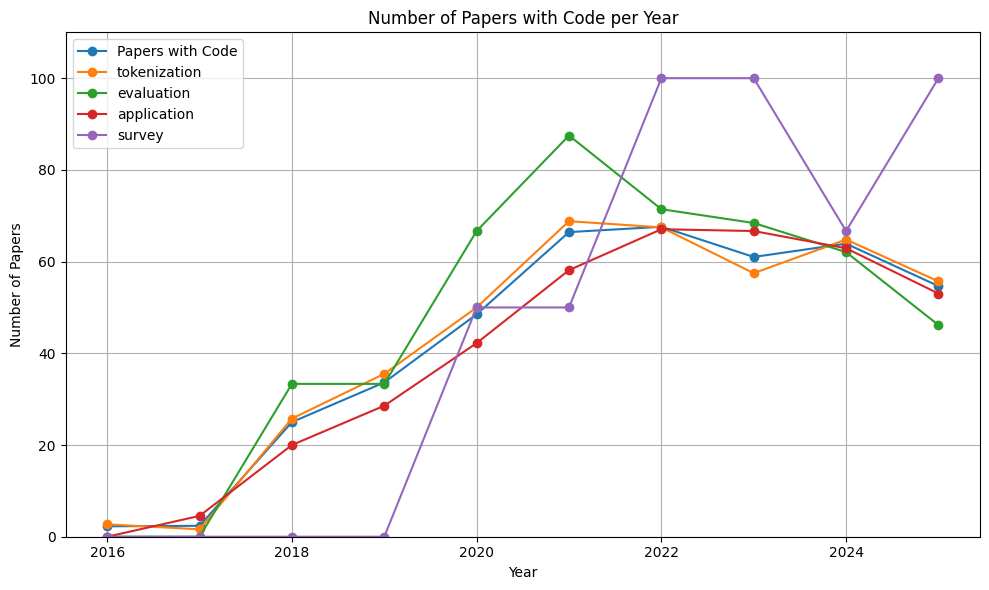

In [4]:
# Plot the number of papers with code over the years
years = sorted(real_tokenization['year'].unique())
code_counts = []
total_counts = []       
plt.figure(figsize=(10, 6))

for year in years:  
    year_data = real_tokenization[real_tokenization['year'] == year]
    code_count = year_data[year_data['has_code'] == True].shape[0]
    total_count = year_data.shape[0]
    code_counts.append(code_count)
    total_counts.append(total_count)
plt.plot(years, [c/t * 100 if t != 0 else 0 for c, t in zip(code_counts, total_counts)], marker='o', label='Papers with Code')

for cat in ['tokenization', 'evaluation', 'application', 'survey']:
    code_counts = []
    total_counts = []  
    for year in years:
        year_data = real_tokenization[(real_tokenization[cat]) & (real_tokenization['year'] == year)]
        code_count = year_data[year_data['has_code'] == True].shape[0]
        total_count = year_data.shape[0]
        code_counts.append(code_count)
        total_counts.append(total_count)
    plt.plot(years, [c/t * 100 if t != 0 else 0 for c, t in zip(code_counts, total_counts)], marker='o', label=cat)


plt.title('Number of Papers with Code per Year')
plt.xlabel('Year')
plt.ylabel('Number of Papers')
plt.ylim(0, 110)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
real_tokenization.to_json('data/real_tokenization.jsonl', orient='records', lines=True)

## Units

- Frequency of each unit
- Number of different units for each paper
- Number of papers using each unit over time

In [ ]:
import tqdm
import llm_filter
import paper_dataset
import importlib
import matplotlib.pyplot as plt
import re
import json
import os
import itertools
import collections
tqdm.tqdm.pandas()

/home/vico/personal_work_ms/TokSurvey/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


INFO 01-15 11:23:03 [__init__.py:220] No platform detected, vLLM is running on UnspecifiedPlatform
WARNING 01-15 11:23:07 [_custom_ops.py:20] Failed to import from vllm._C with ImportError('libcuda.so.1: cannot open shared object file: No such file or directory')


In [21]:
importlib.reload(llm_filter)

<module 'llm_filter' from '/lnet/work/people/vico/TokSurvey/llm_filter.py'>

In [ ]:
real_tokenization = paper_dataset.load('data/real_tokenization.jsonl')
real_tokenization.shape

(2004, 20)

In [ ]:
# all_answers_unit = []
# for answer in llm_filter.get_units(real_tokenization):
#     all_answers_unit.append(answer)
    
# with open('data/raw_answers/unit_answer.json', 'wt') as f:
#     json.dump(all_answers_unit, f, indent=2)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1348/1348 [4:25:32<00:00, 11.82s/it]


In [4]:
with open('data/raw_answers/unit_answer.json') as f:
    all_answers_unit = json.load(f)
all_answers_unit[:5]

['* Words\n* Subwords\n* Characters\n* Bytes\n* Morphemes\n* Phonemes \n* Pitch tokens\n* Style tokens \n* HuBERT tokens',
 '* Tokens \n* Words',
 '* Subwords \n* Tokens \n* Characters \n* Bytes',
 '* Morphemes \n* Subwords \n* Words',
 '* words \n* tokens \n* characters \n* subwords \n* lemmas']

In [60]:
unit_sets = [llm_filter.extract_units(i) for i in all_answers_unit]
unit_sets[:5]

[['bytes',
  'characters',
  'hubert tokens',
  'morphemes',
  'phonemes',
  'pitch tokens',
  'style tokens',
  'subwords',
  'words'],
 ['subwords', 'words'],
 ['bytes', 'characters', 'subwords'],
 ['morphemes', 'subwords', 'words'],
 ['characters', 'lemmas', 'subwords', 'words']]

In [24]:
unique_units = collections.Counter(itertools.chain.from_iterable(unit_sets))
len(unique_units)

696

In [25]:
for i in unique_units.most_common():
    print(i)

('subwords', 1712)
('words', 1169)
('characters', 1159)
('morphemes', 401)
('bytes', 368)
('pixels', 166)
('sentences', 60)
('phonemes', 57)
('patches', 41)
('syllables', 39)
('n-grams', 34)
('frames', 28)
('phrases', 27)
('embeddings', 25)
('nodes', 22)
('edges', 15)
('morphs', 13)
('lemmas', 12)
('stems', 12)
('entities', 12)
('patch tokens', 11)
('suffixes', 11)
('spans', 10)
('phones', 10)
('chunks', 10)
('image tokens', 9)
('sequences', 9)
('roots', 9)
('residues', 9)
('bigrams', 8)
('amino acids', 8)
('latent tokens', 8)
('atoms', 8)
('graphemes', 7)
('affixes', 7)
('subgraphs', 7)
('documents', 7)
('lines', 6)
('acoustic tokens', 6)
('substrings', 6)
('actions', 6)
('strings', 6)
('subsequences', 6)
('blocks', 6)
('symbols', 6)
('images', 6)
('vectors', 6)
('graphs', 6)
('digits', 5)
('signs', 5)
('word', 5)
('paragraphs', 5)
('sub-tokens', 5)
('visual tokens', 5)
('prefixes', 5)
('nucleotides', 5)
('samples', 5)
('clips', 5)
('genes', 5)
('latents', 5)
('passages', 4)
('vision 

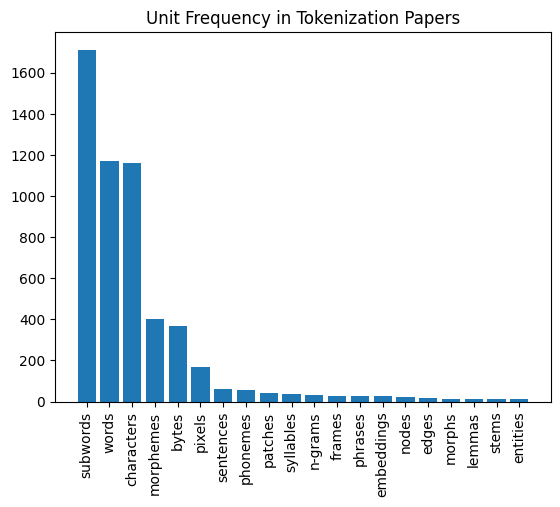

In [30]:
# Plot how many times each unit appears appears in the papers
unit_frequency = collections.Counter()
for units in unit_sets:
    unit_frequency.update(units)
unit_frequency_items = unit_frequency.most_common(20)
units, frequencies = zip(*unit_frequency_items)
plt.bar(units, frequencies)
plt.xticks(rotation=90)
plt.title('Unit Frequency in Tokenization Papers')
plt.show()

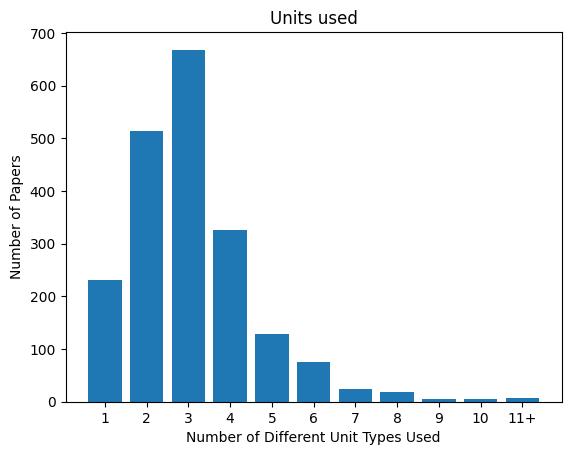

In [49]:
# Types of units per paper
max_ = 11
counts = [len(units) for units in unit_sets]
if max_ in counts:
    raise ValueError("max_ value is in counts, choose a higher value")
counts = [c if c <= max_ else max_ for c in counts]
plt.hist(counts, bins=range(1, max_ + 2), align='left', rwidth=0.8)
plt.xticks(range(1, max_ + 1), labels=[str(i) for i in range(1, max_)] + [f"{max_}+"] )
plt.xlabel('Number of Different Unit Types Used')
plt.ylabel('Number of Papers')
plt.title('Units used')
plt.show()

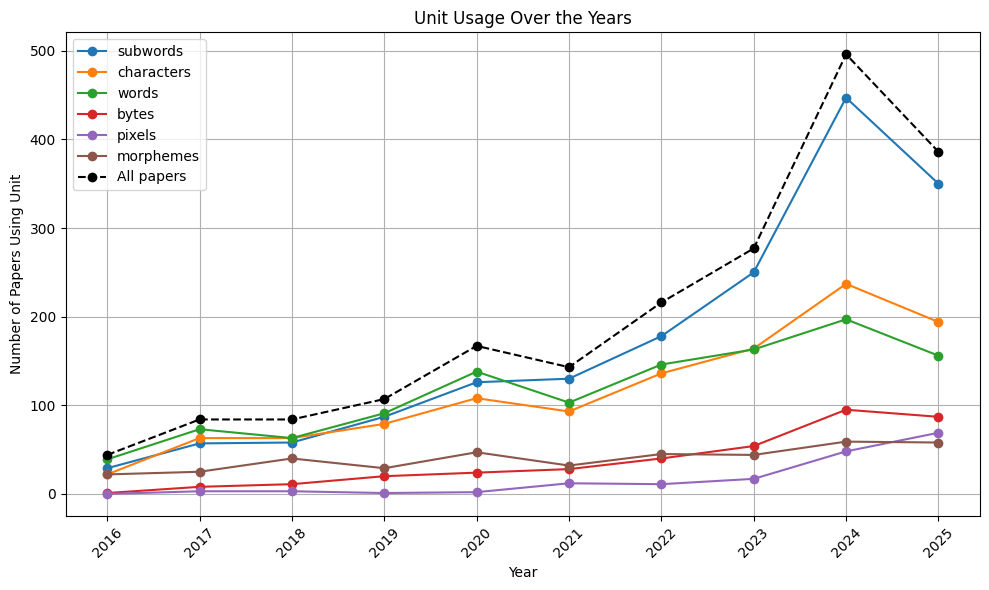

In [64]:
# Count how many times units are used over the years
# Units: subwords, characters, words, bytes, pixels, morphemes
years = real_tokenization.year.to_list()
year_range = list(range(min(years), max(years) + 1))
min_ = min(year_range)
units = ["subwords", "characters", "words", "bytes", "pixels", "morphemes"]
counts = {unit: [0] * len(year_range) for unit in units}
all_counts = [0] * len(year_range)
for unit_set, year in zip(unit_sets, years):
    for unit in units:
        if unit in unit_set:
            counts[unit][year - min_] += 1
    all_counts[year - min_] += 1
plt.figure(figsize=(10, 6))
for unit in units:
    plt.plot(year_range, counts[unit], marker='o', label=unit)
plt.plot(year_range, all_counts, marker='o', label='All papers', linestyle='--', color='black')
    
plt.title('Unit Usage Over the Years')
plt.xlabel('Year')
plt.ylabel('Number of Papers Using Unit')
plt.xticks(year_range, rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()    

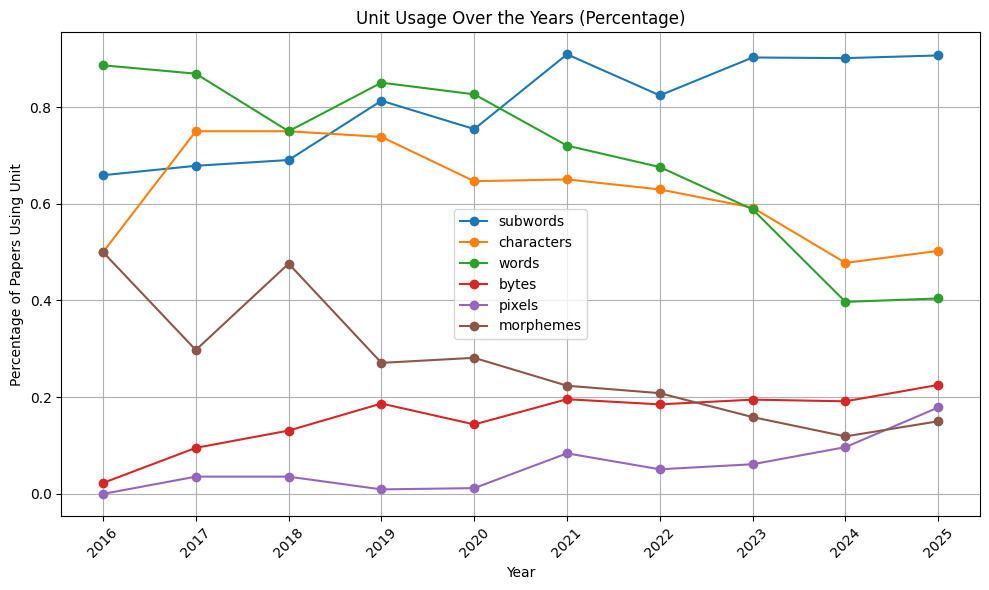

In [66]:
# Count how many times units are used over the years
# Units: subwords, characters, words, bytes, pixels, morphemes
years = real_tokenization.year.to_list()
year_range = list(range(min(years), max(years) + 1))
min_ = min(year_range)
units = ["subwords", "characters", "words", "bytes", "pixels", "morphemes"]
counts = {unit: [0] * len(year_range) for unit in units}
all_counts = [0] * len(year_range)
for unit_set, year in zip(unit_sets, years):
    for unit in units:
        if unit in unit_set:
            counts[unit][year - min_] += 1
    all_counts[year - min_] += 1
plt.figure(figsize=(10, 6))
for unit in units:
    plt.plot(year_range, [i/j if j > 0 else 0 for i, j in zip(counts[unit], all_counts)], marker='o', label=unit)
    
plt.title('Unit Usage Over the Years (Percentage)')
plt.xlabel('Year')
plt.ylabel('Percentage of Papers Using Unit')
plt.xticks(year_range, rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()    

In [28]:
tmp = [i for i in unit_frequency.keys() if 'token' in i]
len(set(tmp))

108

In [29]:
tmp[:10]

['hubert tokens',
 'pitch tokens',
 'style tokens',
 'draft token sequence',
 'prefix tokens',
 'subsequent tokens',
 'token sequences',
 'language tokens',
 'vision tokens',
 'image tokens']

## Metrics

In [256]:
import tqdm
import llm_filter
import paper_dataset
import importlib
import matplotlib.pyplot as plt
import re
import json
import os
import collections
import itertools
import pandas as pd
tqdm.tqdm.pandas()

In [257]:
importlib.reload(llm_filter)

<module 'llm_filter' from '/lnet/work/people/vico/TokSurvey/llm_filter.py'>

In [258]:
real_tokenization = paper_dataset.load('data/real_tokenization.jsonl')
real_tokenization.shape

(2004, 20)

In [259]:
# all_answers_task_metric = []
# for answer in llm_filter.get_metrics_tasks(real_tokenization):
#     all_answers_task_metric.append(answer)
    
# with open('data/raw_answers/metrics_tasks_answer.json', 'wt') as f:
#     json.dump(all_answers_task_metric, f, indent=2)

In [260]:
with open('data/raw_answers/metrics_tasks_answer.json') as f:
    all_answers_task_metric = json.load(f)
all_answers_task_metric[:5]

['* Tokenization: Word Error Rate (WER), Character Error Rate (CER), Bitrate, Content, Expressive Style, Pitch, F0 Frame Error (FFE)\n* Language Modeling: Accuracy, Accuracy-token, Log-likelihood, Perplexity\n* Speech Recognition: Word Error Rate (WER)\n* Text-to-Speech: Character Error Rate (CER)\n* Sentiment Preservation: Accuracy\n* Intent Classification: Accuracy\n* Story Cloze: Accuracy\n* WUGGY: Accuracy\n* BLIMP: Accuracy\n* MMLU: Accuracy',
 '* Speculative Decoding: Mean Acceptance Length, Tokens per Second, Speedup Ratio \n* Tree Construction: Mathematical Expectation of Acceptance Length \n* Drafting: Output Probability, Acceptance Frequency \n* Verification: Acceptance Length, Verification Time \n* Evaluation: Mean Acceptance Length, Tokens per Second, Speedup Ratio \n* Analysis: Time Cost, Threshold Impact \n* Comparison: Mean Acceptance Length, Tokens per Second, Speedup Ratio',
 '* Tokenization Efficiency: Length Per Token (LPT)\n* Task Performance: Exact Match (EM), Char

In [261]:
metric_sets = [llm_filter.extract_tasks_metrics(i) for i in all_answers_task_metric]
metric_sets[:5]

[{'tokenization': ['f0 frame error (ffe)',
   'pitch',
   'content',
   'word error rate',
   'expressive style',
   'character error rate',
   'bitrate'],
  'language modeling': ['accuracy', 'perplexity', 'log-likelihood'],
  'speech recognition': ['word error rate'],
  'text-to-speech': ['character error rate'],
  'sentiment preservation': ['accuracy'],
  'intent classification': ['accuracy'],
  'story cloze': ['accuracy'],
  'wuggy': ['accuracy'],
  'blimp': ['accuracy'],
  'mmlu': ['accuracy']},
 {'decoding': ['mean acceptance length', 'speedup', 'tokens per second'],
  'tree construction': ['mathematical expectation of acceptance length'],
  'drafting': ['acceptance frequency', 'output probability'],
  'verification': ['verification time', 'acceptance length'],
  'model evaluation': ['mean acceptance length',
   'speedup',
   'tokens per second']},
 {'tokenization efficiency': ['length per token (lpt)'],
  'task performance': ['f1 score', 'accuracy', 'exact match', 'bertscore'],
 

In [262]:
tmp = [list(i.keys()) for i in metric_sets]
tmp = set(itertools.chain.from_iterable(tmp))
tmp

{'cross-entropy data selection',
 'information loss',
 'cohort training',
 'word similarity tasks',
 'scd',
 'cost-efficiency',
 'bilingual word embedding',
 'diabetes prediction',
 'length compliance',
 'word embedding learning',
 'token alignment',
 'locality-sensitive hashing (lsh) evaluation',
 'image reconstruction',
 'model interpretation',
 'llms',
 'coqa',
 'entity transcription',
 'explanation',
 'multilingual evaluation metrics',
 'model behavior evaluation',
 'comparison of writing systems',
 'saliency detection',
 'goal-conditioned text generation',
 'image-video understanding',
 'hyponymy detection',
 'model-free reinforcement learning',
 'music understanding',
 'mongolian morpheme segmentation',
 'masked motion modeling',
 'next text region prediction',
 'llamaindex team',
 'reduction scheduling',
 'hyperparameter sensitivity',
 'token detection (td)',
 'random select',
 'morpheme-based ner',
 'syntactic analysis',
 'multi-word token expansion',
 'semantic annotation anal

Tasks: 5822
Papers with task with no metrics: 58
Tasks with no metrics: 95


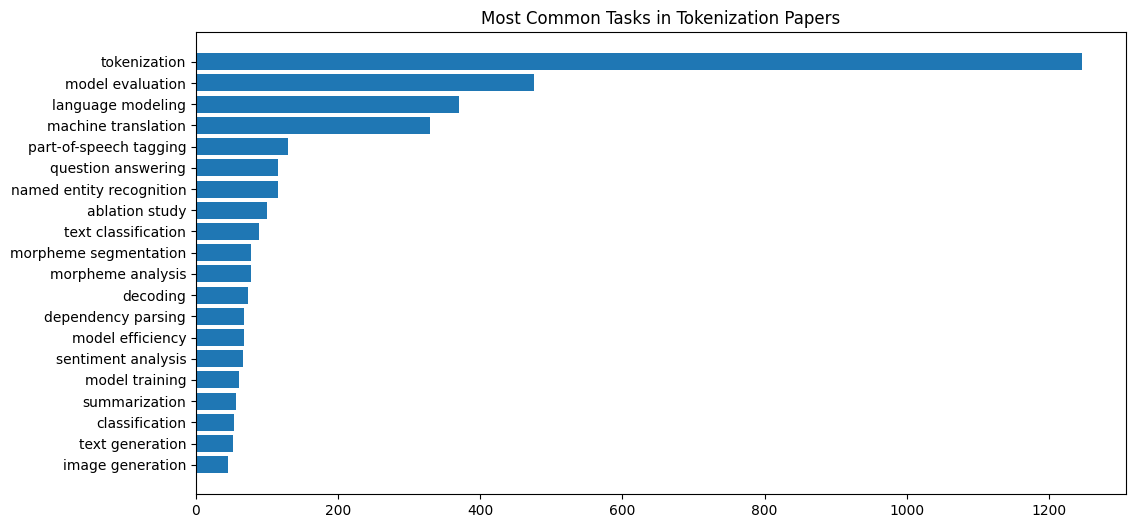

In [263]:
task_frequency = collections.Counter()
tasks_no_metric = set()
paper_task_no_metric = 0
exclude = real_tokenization['exclude'].to_list()
for metrics, ex in zip(metric_sets, exclude):
    if not ex:
        task_frequency.update(metrics.keys())
        if [] in metrics.values():
            paper_task_no_metric += 1
            for task, metric_list in metrics.items():
                if len(metric_list) == 0:
                    tasks_no_metric.add(task)
        
print("Tasks:", len(task_frequency))
print("Papers with task with no metrics:", paper_task_no_metric)
print("Tasks with no metrics:", len(tasks_no_metric))
# for i in task_frequency.most_common(20):
#     print(i)
# Plot most common tasks
most_common_task = task_frequency.most_common(20)
tasks, counts = zip(*most_common_task)
plt.figure(figsize=(12, 6))
plt.barh(tasks, counts)
plt.gca().invert_yaxis()
plt.title('Most Common Tasks in Tokenization Papers')
plt.show()

Metrics: 4994


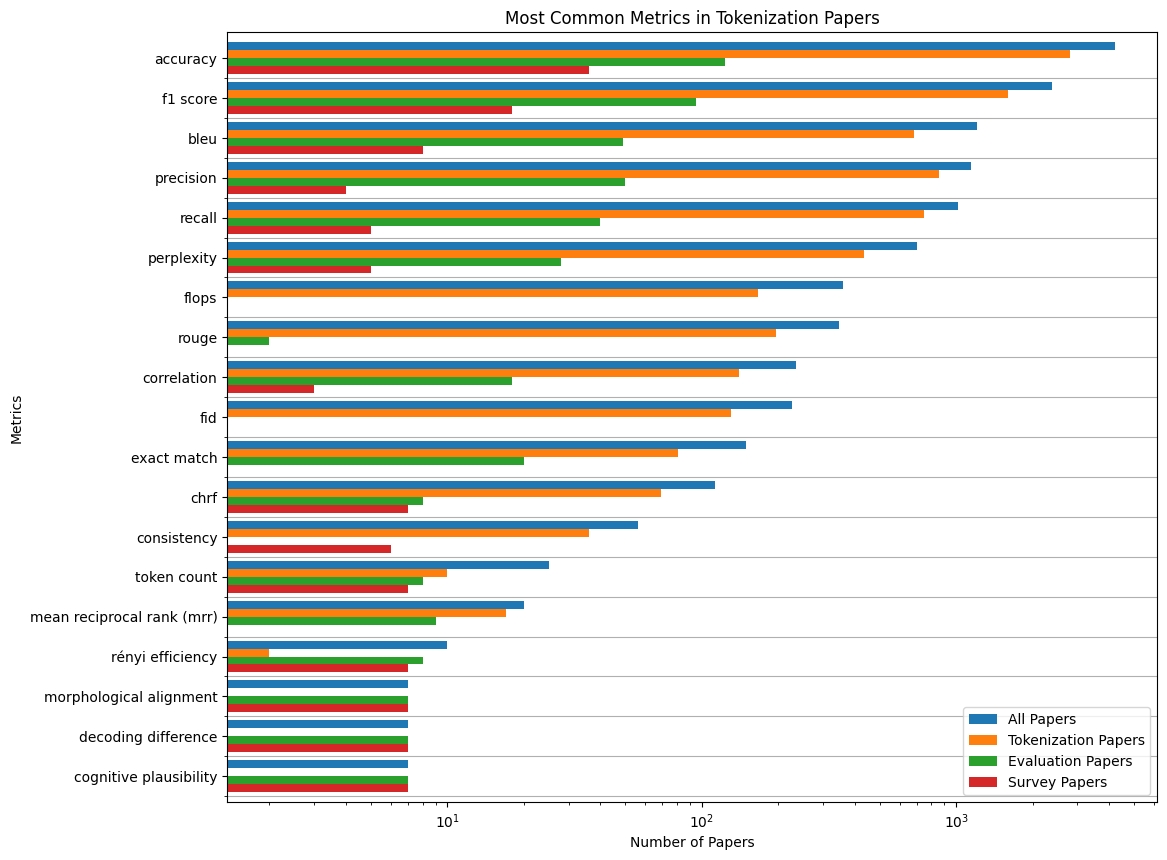

In [275]:
metric_frequency = collections.Counter()
eval_metric_frequency = collections.Counter()
survey_metric_frequency = collections.Counter()
tok_metric_frequency = collections.Counter()
for metrics, info in zip(metric_sets, real_tokenization.iloc):
    ev = info['evaluation']
    sv = info['survey']
    tk = info['tokenization']
    for metric_list in metrics.values():
        metric_frequency.update(metric_list)
        if ev:
            eval_metric_frequency.update(metric_list)
        if sv:
            survey_metric_frequency.update(metric_list)
        if tk:
            tok_metric_frequency.update(metric_list)
print("Metrics:", len(metric_frequency))

# Plot most common metrics, grouped by category
n = 10
most_common_metric = metric_frequency.most_common(n)
tok_common_metric = tok_metric_frequency.most_common(n)
eval_common_metric = eval_metric_frequency.most_common(n)
survey_common_metric = survey_metric_frequency.most_common(n)

metrics, _ = zip(*most_common_metric)
tok_metrics, _ = zip(*tok_common_metric)
eval_metrics, _ = zip(*eval_common_metric)
survey_metrics, _ = zip(*survey_common_metric)

plot_metrics = list(set(metrics) | set(tok_metrics) | set(eval_metrics) | set(survey_metrics))
counts = [metric_frequency[m] for m in plot_metrics]
plot_metrics = sorted(plot_metrics, key=lambda x: metric_frequency[x], reverse=True)
counts = [metric_frequency[m] for m in plot_metrics]

tok_counts = [tok_metric_frequency[m] for m in plot_metrics]
eval_counts = [eval_metric_frequency[m] for m in plot_metrics]
survey_counts = [survey_metric_frequency[m] for m in plot_metrics]

df = pd.DataFrame({
    'Metric': plot_metrics,
    'All Papers': counts,
    'Tokenization Papers': tok_counts,
    'Evaluation Papers': eval_counts,
    'Survey Papers': survey_counts
})  

df.plot.barh(layout='tight', figsize=(12, 10), width=0.8) 
plt.xlabel('Number of Papers')
plt.xscale('log')
plt.ylabel('Metrics')
plt.yticks(range(len(plot_metrics)), labels=plot_metrics)
plt.yticks([i+0.5 for i in range(len(plot_metrics))], minor=True)
plt.grid(which='minor', axis='y')
plt.title('Most Common Metrics in Tokenization Papers')
plt.gca().invert_yaxis()
plt.legend()
plt.show()

Papers with intrinsic tasks: 548
Papers with extrinsic tasks: 2004


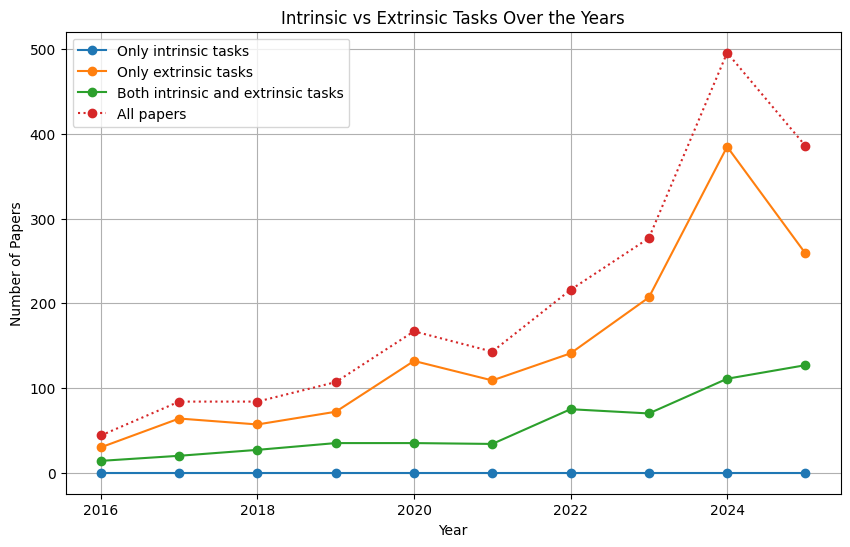

In [276]:
intrinsic_tasks = ['language modeling', 'word segmentation', 'segmentation', 'morpheme segmentation', 'subwording', 'model efficiency']
is_intrinsic = []
is_extrinsic = []
for metrics in metric_sets:
    if len(metrics) == 0:
        is_intrinsic.append(False)
        is_extrinsic.append(False)
    else:
        tasks = list(metrics.keys())
        has_intrinsic = any(intrinsic_task in tasks for intrinsic_task in intrinsic_tasks)
        is_intrinsic.append(has_intrinsic)
        has_extrinsic = any(intrinsic_task not in tasks for intrinsic_task in intrinsic_tasks)
        is_extrinsic.append(has_extrinsic)
print("Papers with intrinsic tasks:", sum(is_intrinsic))
print("Papers with extrinsic tasks:", sum(is_extrinsic))
years = real_tokenization.year.to_list()
year_range = list(range(min(years), max(years) + 1))
min_ = min(year_range)
int_only_counts = [0] * len(year_range)
ext_only_counts = [0] * len(year_range)
int_ext_counts = [0] * len(year_range)
all_counts = [0] * len(year_range)
for intrinsic, extrinsic, year in zip(is_intrinsic, is_extrinsic, years):
    if intrinsic and extrinsic:
        int_ext_counts[year - min_] += 1
    elif intrinsic:
        int_only_counts[year - min_] += 1
    elif extrinsic:
        ext_only_counts[year - min_] += 1    
    all_counts[year - min_] += 1
plt.figure(figsize=(10, 6))
plt.plot(year_range, int_only_counts, marker='o', label='Only intrinsic tasks')
plt.plot(year_range, ext_only_counts, marker='o', label='Only extrinsic tasks')
plt.plot(year_range, int_ext_counts, marker='o', label='Both intrinsic and extrinsic tasks')
plt.plot(year_range, all_counts, marker='o', linestyle=":", label='All papers')
plt.xlabel('Year')
plt.ylabel('Number of Papers')
plt.title('Intrinsic vs Extrinsic Tasks Over the Years')
plt.legend()
plt.grid()
plt.show()

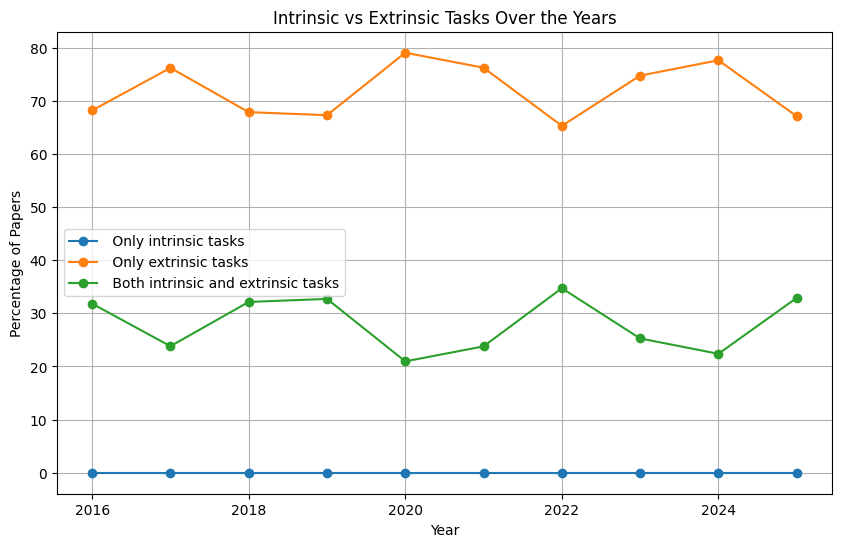

In [277]:
# Plot the percentage of intrinsic and extrinsic tasks over the years
plt.figure(figsize=(10, 6))
plt.plot(year_range, [i/j * 100 if j > 0 else 0 for i, j in zip(int_only_counts, all_counts)], marker='o', label=' Only intrinsic tasks')
plt.plot(year_range, [i/j * 100 if j > 0 else 0 for i, j in zip(ext_only_counts, all_counts)], marker='o', label=' Only extrinsic tasks')
plt.plot(year_range, [i/j * 100 if j > 0 else 0 for i, j in zip(int_ext_counts, all_counts)], marker='o', label=' Both intrinsic and extrinsic tasks')
plt.xlabel('Year')
plt.ylabel('Percentage of Papers')
plt.title('Intrinsic vs Extrinsic Tasks Over the Years')
plt.legend()
plt.grid()
plt.show()

## Motivations

In [5]:
import tqdm
import llm_filter
import paper_dataset
import importlib
import matplotlib.pyplot as plt
import re
import json
import os
import motivation_clustering
import torch
import collections
tqdm.tqdm.pandas()

In [2]:
importlib.reload(motivation_clustering)

<module 'motivation_clustering' from '/lnet/work/people/vico/TokSurvey/motivation_clustering.py'>

In [16]:
real_tokenization = paper_dataset.load('data/real_tokenization.jsonl')
excluded = (real_tokenization['exclude']).to_list()
real_tokenization.shape

(2004, 20)

In [ ]:
# all_answers_motivation = []
# for answer in llm_filter.get_units(real_tokenization):
#     all_answers_motivation.append(answer)
    
# with open('data/raw_answers/motivation_answer.json', 'wt') as f:
#     json.dump(all_answers_motivation, f, indent=2)

In [36]:
with open('data/raw_answers/motivation_answer.json') as f:
    raw_motivations = json.load(f)
raw_motivations[:5]

['to develop a foundation multimodal language model, called S PI R IT -LM, that can generate both speech and text in a cross-modal manner, by combining the generative abilities and pretrained knowledge of text language models with the expressive capacities of speech-language models.',
 'The main motivation behind the research presented in the paper is to improve the efficiency of autoregressive language models by developing an adaptive and scalable tree structure called OPT-Tree for speculative decoding, which can accelerate decoding while maintaining the original output distribution.',
 'The main motivation behind the research presented in the paper is to develop an efficient method for optimizing tokenizers for non-English languages without increasing vocabulary size, thereby enhancing token efficiency and performance for multilingual language models.',
 'to address the issue of analyzing and generating Indonesian words by creating a morphology engine, IndoMorph, that can handle the 

In [24]:
# Count prefixes
prefix_counts = collections.Counter()
n = 11
for answer, exclude in zip(raw_motivations, excluded):
    if not exclude:
        prefix = " ".join(answer.split()[:n])
        prefix_counts[prefix] += 1
prefix_counts.most_common(10)

[('The main motivation behind the research presented in the paper is', 1353),
 ('to develop a novel Vision-Language-Action (VLA) model, called OmniJARVIS, that enables',
  2),
 ('to address the issue of excessive truncation in large language model', 2),
 ('to improve the performance and robustness of Mixture-of-Experts (MoE) models by',
  2),
 ('to develop a foundation multimodal language model, called S PI R', 1),
 ('to address the issue of analyzing and generating Indonesian words by', 1),
 ('to uncover the origins of entity-related cultural biases in language models,',
  1),
 ('to address the lack of high-quality, open-source, and open-access text-to-speech datasets',
  1),
 ('to develop a novel approach called S^2-MAD that reduces the token', 1),
 ('to enhance the function-calling capabilities of large language models (LLMs) by',
  1)]

In [38]:
prefixes = ["The main motivation behind the research presented in the paper is", "to",]
for prefix in prefixes:
    raw_motivations = [i.removeprefix(prefix).strip() for i in raw_motivations]
raw_motivations[:5]

['develop a foundation multimodal language model, called S PI R IT -LM, that can generate both speech and text in a cross-modal manner, by combining the generative abilities and pretrained knowledge of text language models with the expressive capacities of speech-language models.',
 'improve the efficiency of autoregressive language models by developing an adaptive and scalable tree structure called OPT-Tree for speculative decoding, which can accelerate decoding while maintaining the original output distribution.',
 'develop an efficient method for optimizing tokenizers for non-English languages without increasing vocabulary size, thereby enhancing token efficiency and performance for multilingual language models.',
 'address the issue of analyzing and generating Indonesian words by creating a morphology engine, IndoMorph, that can handle the complex morphology of the Indonesian language, a low-resource language in the NLP field.',
 'improve the accuracy of lemmatization in the Estoni

In [67]:
motivations = [i for i, e in zip(raw_motivations, excluded) if not e]
len(motivations)

1942

In [68]:
embs = motivation_clustering.get_motivation_embeddings(motivations)
torch.save(embs, 'data/raw_answers/motivation_embeddings.pt')
embs = torch.load('data/raw_answers/motivation_embeddings.pt')
embs.shape

Batches:   0%|          | 0/61 [00:00<?, ?it/s]

torch.Size([1942, 768])

In [69]:
embs_2d = motivation_clustering.embeddings_TSNE(embs, n_components=2)
embs_3d = motivation_clustering.embeddings_TSNE(embs, n_components=3)
embs_2d.shape

(1942, 2)

In [70]:
cluster, labels = motivation_clustering.cluster_motivations(embs, threshold=0.5, min_samples=20)
cluster = {k: [motivations[i] for i in v] for k,v in enumerate(cluster)}
len(cluster)

Finding clusters:   0%|          | 0/2 [00:00<?, ?it/s]

18

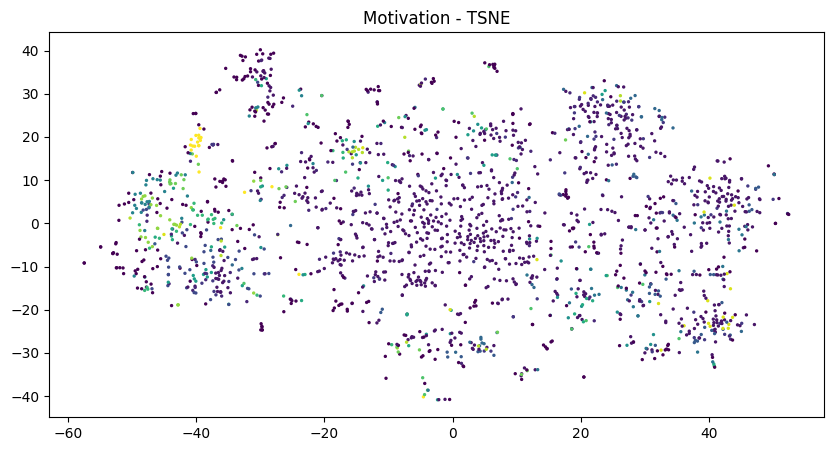

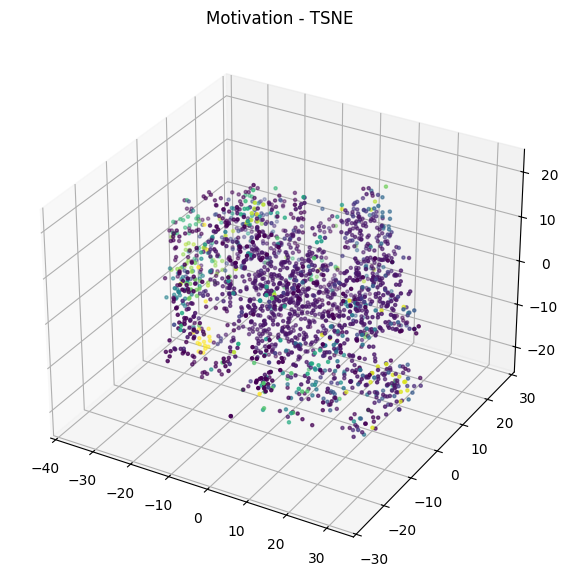

In [71]:
motivation_clustering.plot_clusters_2d(embs_2d, labels, "Motivation - TSNE")
motivation_clustering.plot_clusters_3d(embs_3d, labels, "Motivation - TSNE")

In [95]:
STOP = ['a', 'about', 'again', 'ain', 'am', 'an', 'and', 'are', 'aren', "aren't", 'at', 'be', 'because', 'been', 'being', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'during', 'each', 'for', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', 'her', 'here', 'hers', 'herself', 'him', 'himself', 'his', 'i', 'in', 'into', 'is', 'isn', "isn't", 'it', "it's", 'its', 'itself', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'or', 'ourselves', 'out', 'own', 're', 's', 'shan', "shan't", 'she', "she's", 'should', "should've", 'shouldn', "shouldn't", 'so', 'such', 't', 'that', "that'll", 'the', 'their', 'theirs', 'them', 'themselves', 'then', 'there', 'these', 'they', 'this', 'those', 'through', 'to', 'too', 'until', 've', 'very', 'was', 'wasn', "wasn't", 'we', 'were', 'weren', "weren't", 'will', 'with', 'won', "won't", 'wouldn', "wouldn't", 'y', 'you', "you'd", "you'll", "you're", "you've", 'your', 'yours', 'yourself', 'yourselves']

motivation_stops = [" ".join(word for word in motivation.split() if word not in STOP) for motivation in motivations]
motivation_stops[:5]

['develop foundation multimodal language model, called S PI R IT -LM, generate both speech text cross-modal manner, combining generative abilities pretrained knowledge text language models expressive capacities speech-language models.',
 'improve efficiency autoregressive language models developing adaptive scalable tree structure called OPT-Tree speculative decoding, which accelerate decoding while maintaining original output distribution.',
 'develop efficient method optimizing tokenizers non-English languages without increasing vocabulary size, thereby enhancing token efficiency performance multilingual language models.',
 'address issue analyzing generating Indonesian words creating morphology engine, IndoMorph, handle complex morphology Indonesian language, low-resource language NLP field.',
 'improve accuracy lemmatization Estonian language integrating external disambiguation model rule-based morphological analyzer evaluate impact downstream information retrieval task.']

In [165]:
from bertopic import BERTopic
from llm_pipeline import _sentence_encoder
from bertopic.representation import MaximalMarginalRelevance
from sklearn.cluster import AgglomerativeClustering, KMeans, OPTICS, AffinityPropagation

ag = AgglomerativeClustering(n_clusters=35)
ap = AffinityPropagation()
op = OPTICS(min_samples=10)
km = KMeans(n_clusters=40)

representation_model = MaximalMarginalRelevance(diversity=0.2)

model = BERTopic(embedding_model=_sentence_encoder(), min_topic_size=10, calculate_probabilities=True, hdbscan_model=ag, representation_model=representation_model)
motivation_topics, probs = model.fit_transform(motivation_stops)
# motivation_topics = model.reduce_outliers(motivation_stops, motivation_topics, strategy="embeddings", embeddings=embs)
# model.update_topics(motivation_stops, motivation_topics)

In [166]:
model.get_topic_info()#["Count"].sum()

,Topic,Count,Name,Representation,Representative_Docs
0,0,105,0_translation_neural_improve_subword,"[translation, neural, improve, subword, resour...",[develop simple efficient multilingual neural ...
1,1,95,1_morphological_arabic_morphology_languages,"[morphological, arabic, morphology, languages,...",[improve Arabic diacritization introducing cha...
2,2,93,2_multimodal_visual_vision_mllms,"[multimodal, visual, vision, mllms, modal, mod...",[explore design space visual context represent...
3,3,92,3_token_language_code_tokens,"[token, language, code, tokens, address, byte,...",[improve Direct Preference Optimization (DPO) ...
4,4,85,4_tokenization_subword_encoding_languages,"[tokenization, subword, encoding, languages, k...",[improve performance language models enhancing...
5,5,85,5_trained_domain_pretraining_adversarial,"[trained, domain, pretraining, adversarial, ai...",[improve performance pre-trained language mode...
6,6,85,6_chinese_segmentation_word_tagging,"[chinese, segmentation, word, tagging, part, p...",[address domain adaptation problem Chinese Wor...
7,7,77,7_diffusion_visual_generative_quality,"[diffusion, visual, generative, quality, autor...","[develop joint image-video tokenizer, called O..."
8,8,76,8_word_embeddings_subword_embedding,"[word, embeddings, subword, embedding, represe...",[improve word embeddings utilizing subword-lev...
9,9,74,9_morphological_segmentation_languages_morphemes,"[morphological, segmentation, languages, morph...",[investigate effectiveness convolutional neura...


In [168]:
years = real_tokenization[~real_tokenization['exclude']]['year'].to_list()
topics_over_time = model.topics_over_time(motivations, years)
model.visualize_topics_over_time(topics_over_time, normalize_frequency=True, top_n_topics=10)

In [169]:
hierarchical_topics = model.hierarchical_topics(motivation_stops, use_ctfidf=True)

# Print topic tree
tree = model.get_topic_tree(hierarchical_topics, tight_layout=True)
print(tree)

100%|██████████| 34/34 [00:09<00:00,  3.65it/s]

.
├─language_model_token_learning_training
│ ├─graph_series_data_learning_molecular
│ │ ├─graph_molecular_rna_molecule_cell
│ │ │ ├─■──graph_transformer_generative_nodes_gnn ── Topic: 32
│ │ │ └─■──molecular_rna_genome_molecule_proteins ── Topic: 22
│ │ └─series_motion_forecasting_learning_framework
│ │   ├─■──series_forecasting_data_brain_multivariate ── Topic: 19
│ │   └─motion_learning_driving_environments_human
│ │     ├─■──motion_autonomous_gaze_3d_following ── Topic: 28
│ │     └─■──reinforcement_learning_expert_tuning_router ── Topic: 30
│ └─language_token_generation_model_training
│   ├─vision_images_multimodal_transformers_diffusion
│   │ ├─multimodal_images_vision_diffusion_language
│   │ │ ├─■──diffusion_visual_generative_quality_autoregressive ── Topic: 7
│   │ │ └─■──multimodal_visual_vision_mllms_modal ── Topic: 2
│   │ └─■──vision_transformers_token_spatial_transformer ── Topic: 21
│   └─language_token_training_improve_text
│     ├─attention_decoding_while_memory_computa

In [170]:
topic_labels = model.generate_topic_labels(nr_words=10, separator=", ")
topic_labels

['0, translation, neural, improve, subword, resource, multilingual, languages, vocabulary, byte, word',
 '1, morphological, arabic, morphology, languages, dialectal, corpus, segmentation, japanese, linguistic, morphologically',
 '2, multimodal, visual, vision, mllms, modal, model, training, object, computational, representations',
 '3, token, language, code, tokens, address, byte, tokenization, optimization, trained, retrieval',
 '4, tokenization, subword, encoding, languages, korean, processing, morphological, nlp, vocabulary, tokenizers',
 '5, trained, domain, pretraining, adversarial, ai, vocabulary, improve, adapt, text, learning',
 '6, chinese, segmentation, word, tagging, part, poetry, words, accuracy, labeling, utilizes',
 '7, diffusion, visual, generative, quality, autoregressive, content, representation, videos, tokenization, token',
 '8, word, embeddings, subword, embedding, representations, vocabulary, korean, language, model, semantic',
 '9, morphological, segmentation, lan

In [175]:
model.visualize_hierarchy(hierarchical_topics=hierarchical_topics, use_ctfidf=True)

## Languages

In [2]:
import tqdm
import llm_filter
import paper_dataset
import importlib
import matplotlib.pyplot as plt
import re
import json
import os
import collections
import itertools
from pyglottolog import Glottolog, fts 
import dotenv
from thefuzz import fuzz, process
import language_data
dotenv.load_dotenv()
tqdm.tqdm.pandas()
glottolog = Glottolog(os.getenv('GLOTTOLOG_REPOS'), cache=True)

In [1]:
# !glottolog --repos $GLOTTOLOG_REPOS searchindex

In [124]:
importlib.reload(llm_filter)
importlib.reload(language_data)

<module 'language_data' from '/lnet/work/people/vico/TokSurvey/language_data.py'>

In [123]:
real_tokenization = paper_dataset.load('data/real_tokenization.jsonl')
real_tokenization.shape

(2004, 20)

In [ ]:
# all_answers_languages = []
# for answer in llm_filter.get_units(real_tokenization):
#     all_answers_languages.append(answer)
    
# with open('data/raw_answers/language_answer.json', 'wt') as f:
#     json.dump(all_answers_languages, f, indent=2)

In [11]:
with open('data/raw_answers/language_answer.json') as f:
    all_answers_languages = json.load(f)
all_answers_languages[:5]

['English, French, Belgian, North American English',
 '* English \n* Chinese',
 '* Japanese\n* Chinese\n* English',
 '1. Indonesian\n2. Standard Malay\n3. Finnish\n4. Turkish\n5. Japanese\n6. Tagalog\n7. Javanese\n8. Balinese',
 '* Estonian\n* English\n* Basque\n* Russian\n* Spanish']

In [12]:
# search with glottolog: name (language), name (dialect), name (family)
# search_langs(glottolog, 'North American English', name="North American English", limit=1)
# Missing: check manually
# Traditional Chinese: use as mandarin

In [13]:
lang_sets = [llm_filter.extract_languages(i) for i in all_answers_languages]
all_langs = sorted(list(set(itertools.chain.from_iterable(lang_sets))))
print(len(all_langs), 'languages found before cleaning')

1032 languages found before cleaning


In [ ]:
# REMOVE
GL = list(glottolog.languoids())
GL_NAMES = [l.name for l in GL]

glottolangs = []
missing_langs = []
for lang in tqdm.tqdm(all_langs):
    n, l = fts.search_langs(glottolog, "", name=lang, limit=10)
    if n == 0:
        missing_langs.append(lang)
    else:
        glottolangs.append(l[0])

matches = []
for i in tqdm.tqdm(missing_langs):
    n, l = fts.search_langs(glottolog, i, limit=5)
    tmp_names = [ll.name for ll in l]
    if len(tmp_names) == 0:        
        matches.append((i, None))
    else:
        matches.append((i, process.extractBests(i, tmp_names)))

for i in matches:
    print(i)

100%|██████████| 1032/1032 [01:20<00:00, 12.84it/s]


In [125]:
language_data.map_to_glottolog("Chinese").family

<Family sino1245>

In [126]:
glottolang_sets = []
for lang_set in tqdm.tqdm(lang_sets):
    lset = set()
    for lang in lang_set:                    
        languoid = language_data.map_to_glottolog(lang)
        lset.add(languoid)
    glottolang_sets.append(lset)

100%|██████████| 2004/2004 [00:00<00:00, 255172.59it/s]


In [128]:
macroareas = collections.Counter()
russian_languages = 0
macroareas_sets = []
rep = {"Eurasia": "Asia"}
for glottolang_set, exclude in tqdm.tqdm(zip(glottolang_sets, real_tokenization["exclude"].to_list())):
    if exclude:
        continue
    areas = set()
    russia = False
    for lang in glottolang_set:
        if language_data.is_european(lang):
            areas.add("Europe")
        elif language_data.is_exclusive_russian(lang):
            areas.add("Europe")
            russia = True
        else:
            areas.update(language_data.get_macroarea(lang, rep))
    if russia:
        russian_languages += 1
    if len(areas) == 0:
        areas = {"None",}
    total += 1
    macroareas.update(areas)
    macroareas_sets.append(tuple(sorted(list(areas))))
for i in macroareas.most_common():
    print(i)
print("russia:", russian_languages)
for i in collections.Counter(macroareas_sets).most_common():
    print(i)

2004it [00:00, 2445.25it/s]

('Europe', 1819)
('Asia', 776)
('None', 439)
('Africa', 136)
('North America', 61)
('Papunesia', 48)
('South America', 16)
('Australia', 2)
russia: 37
(('Europe',), 925)
(('Asia', 'Europe'), 498)
(('Asia', 'Europe', 'None'), 124)
(('Europe', 'None'), 95)
(('None',), 91)
(('Africa', 'Asia', 'Europe', 'None'), 41)
(('Africa', 'Europe'), 18)
(('Africa', 'Asia', 'Europe'), 17)
(('Asia',), 15)
(('Africa', 'Asia', 'Europe', 'None', 'Papunesia'), 13)
(('Asia', 'Europe', 'None', 'North America'), 9)
(('Europe', 'None', 'North America'), 8)
(('Africa', 'Asia', 'Europe', 'None', 'North America', 'Papunesia', 'South America'), 8)
(('Africa', 'Asia', 'Europe', 'None', 'North America', 'Papunesia'), 8)
(('Asia', 'Europe', 'North America'), 8)
(('Africa', 'Europe', 'None'), 8)
(('Asia', 'Europe', 'None', 'Papunesia'), 7)
(('Asia', 'None'), 6)
(('Europe', 'North America'), 5)
(('Europe', 'Papunesia'), 4)
(('Africa', 'Asia', 'Europe', 'None', 'North America'), 4)
(('Asia', 'Europe', 'Papunesia'), 3)
(

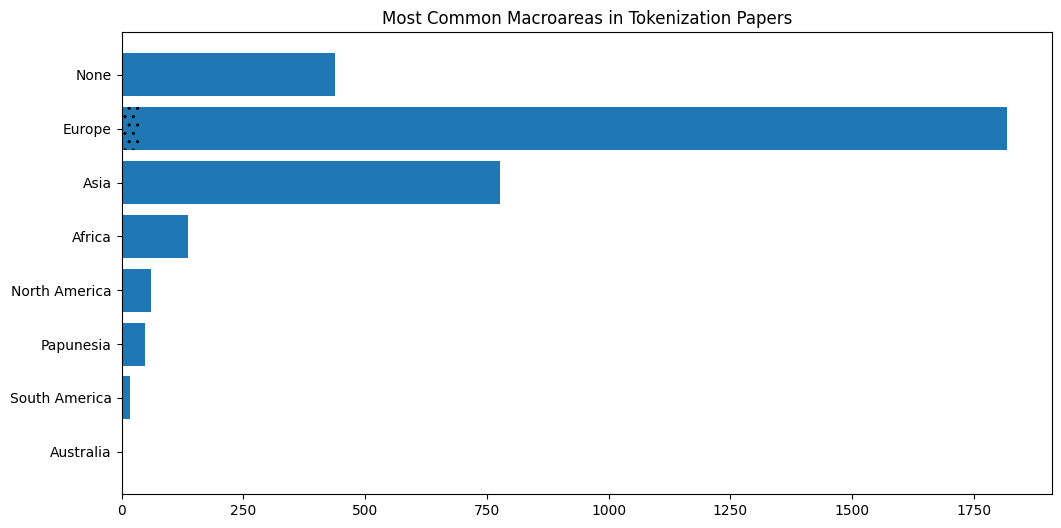

In [129]:
# Plot macroarea counts, overlap bars with Europe (filled) and Russia (hatched)
areas = [ "None", "Europe", "Asia", "Africa", "North America", "Papunesia", "South America", "Australia"]
counts = [macroareas[area] for area in areas]
plt.figure(figsize=(12, 6))
plt.barh(areas, counts)
plt.barh(["Europe"], [russian_languages], color='C0', hatch='..', label='Russia')

plt.gca().invert_yaxis()
plt.title('Most Common Macroareas in Tokenization Papers')
plt.show()

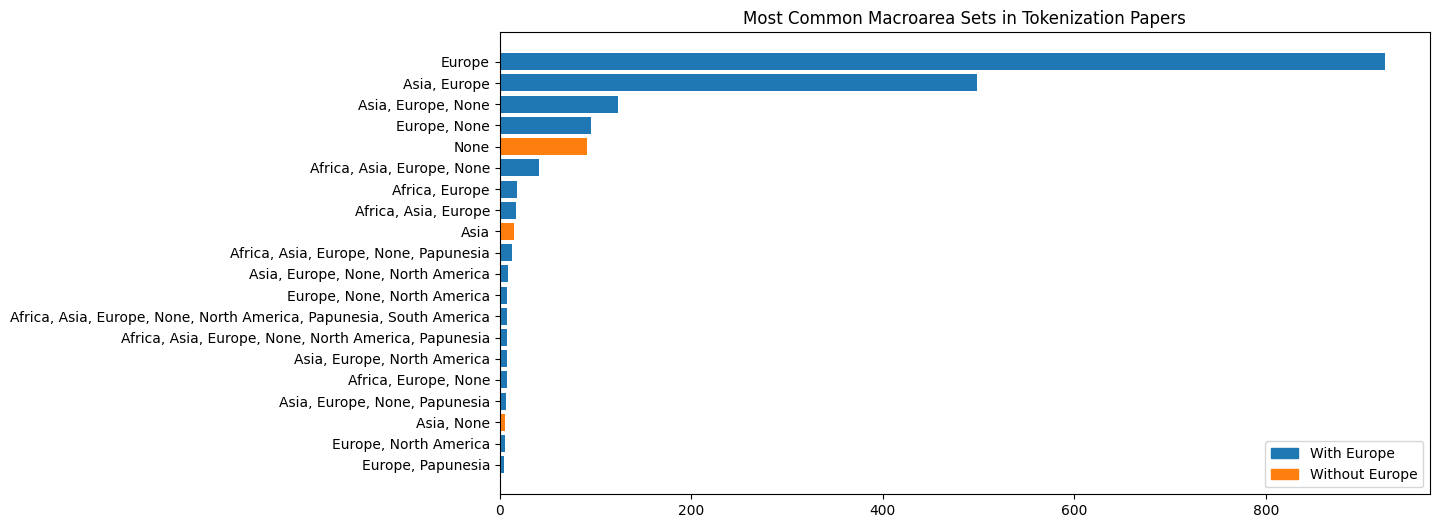

In [130]:
# Plot collections.Counter(macroareas_sets).most_common()
plt.figure(figsize=(12, 6))
macroarea_set_counts = collections.Counter(macroareas_sets).most_common()
labels, counts = zip(*macroarea_set_counts[:20])
labels = [", ".join(label) for label in labels]
plt.barh(labels, counts, color=['C0' if 'Europe' in label else 'C1' for label in labels])
plt.gca().invert_yaxis()
plt.title('Most Common Macroarea Sets in Tokenization Papers')
# Add a legend for Europe color
plt.gca().legend(handles=[plt.Rectangle((0,0),1,1, color='C0'), plt.Rectangle((0,0),1,1, color='C1')], labels=['With Europe', 'Without Europe'], loc='lower right')    
plt.show()

1942it [00:00, 422191.38it/s]


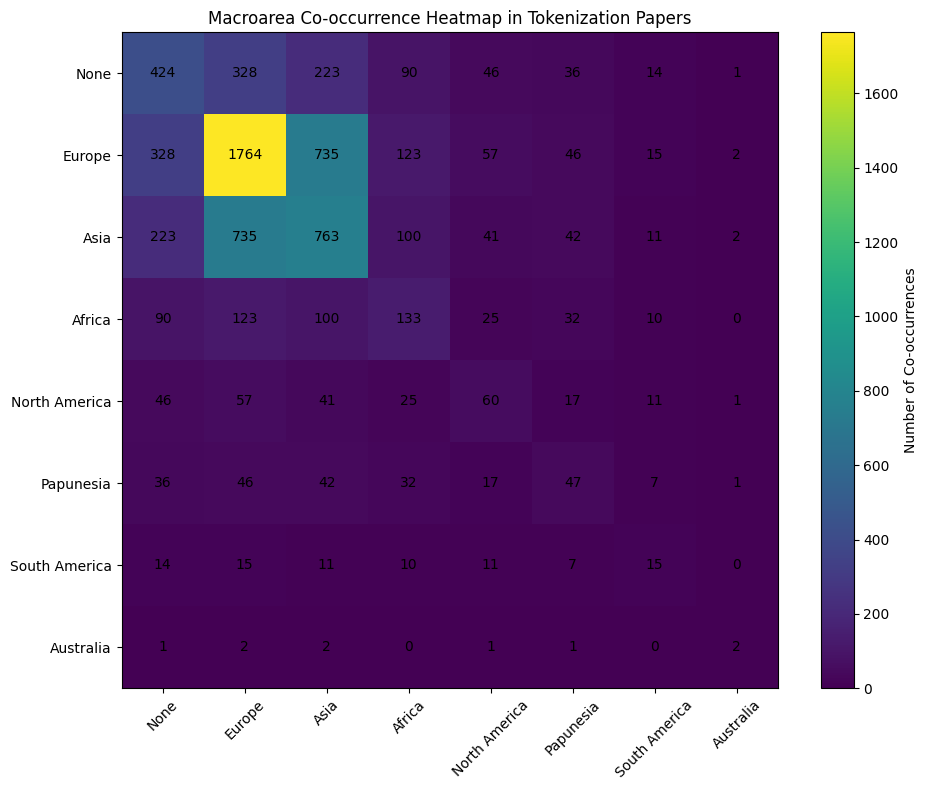

In [131]:
# Plot heatmap of macroarea co-occurrences with text labels
import numpy as np
area_indices = {area: idx for idx, area in enumerate(areas)}
co_occurrence = np.zeros((len(areas), len(areas)), dtype=int)
for macroarea_set, exclude in tqdm.tqdm(zip(macroareas_sets, real_tokenization["exclude"].to_list())):
    if exclude:
        continue
    for area1 in macroarea_set:
        for area2 in macroarea_set:
            idx1 = area_indices[area1]
            idx2 = area_indices[area2]
            co_occurrence[idx1, idx2] += 1
plt.figure(figsize=(10, 8))
plt.imshow(co_occurrence)
# Add text labels
for i in range(len(areas)):
    for j in range(len(areas)):
        plt.text(j, i, str(co_occurrence[i, j]), ha='center', va='center', color='black')
plt.xticks(range(len(areas)), areas, rotation=45)
plt.yticks(range(len(areas)), areas)
plt.colorbar(label='Number of Co-occurrences')
plt.title('Macroarea Co-occurrence Heatmap in Tokenization Papers')
plt.tight_layout()
plt.show()

In [132]:
family_counts = collections.Counter()
for glottolang_set, exclude in tqdm.tqdm(zip(glottolang_sets, real_tokenization["exclude"].to_list())):
    if exclude:
        continue
    families = set()
    for lang in glottolang_set:
        family = language_data.get_family(lang)
        if family is None:
            family = "None"
        families.add(family)
    for family in families:
        family_counts[family] += 1
for i in family_counts.most_common(20):
    print(i)

2004it [00:00, 3479.67it/s]

('Indo-European', 1822)
('Sino-Tibetan', 493)
('None', 371)
('Afro-Asiatic', 248)
('Japonic', 239)
('Turkic', 202)
('Uralic', 179)
('Koreanic', 130)
('Atlantic-Congo', 100)
('Austroasiatic', 99)
('Dravidian', 82)
('Tai-Kadai', 68)
('Austronesian', 45)
('Mongolic-Khitan', 45)
('Kartvelian', 34)
('Uto-Aztecan', 21)
('Algic', 16)
('Artificial Language', 13)
('Arawakan', 13)
('Eskimo-Aleut', 11)


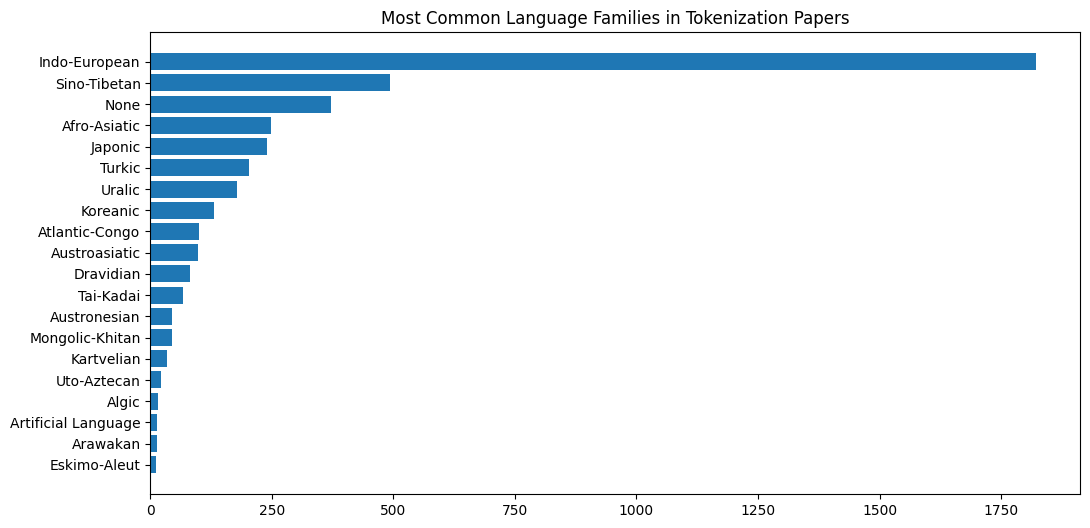

In [136]:
# Plot family counts
most_common_families = family_counts.most_common(20)
families, counts = zip(*most_common_families)
plt.figure(figsize=(12, 6))
plt.barh(families, counts)
plt.gca().invert_yaxis()
plt.title('Most Common Language Families in Tokenization Papers')
plt.show()

In [138]:
unique_languages = list(set(itertools.chain.from_iterable(glottolang_sets)))
len(unique_languages)

680

In [141]:
freq = collections.Counter()
for langs in glottolang_sets:
    freq.update([i.name if i else 'None' for i in langs])
freq.most_common(20)

[('English', 1783),
 ('Chinese', 463),
 ('German', 409),
 ('None', 362),
 ('French', 317),
 ('Spanish', 260),
 ('Japanese', 239),
 ('Arabic', 218),
 ('Russian', 189),
 ('Turkish', 184),
 ('Italian', 158),
 ('Hindi', 148),
 ('Finnish', 139),
 ('Korean', 129),
 ('Czech', 122),
 ('Portuguese', 110),
 ('Dutch', 108),
 ('Vietnamese', 94),
 ('Romanian', 93),
 ('Hungarian', 79)]

In [142]:
freq.most_common()[-10:]

[('Toposa', 1),
 ('Dagbani', 1),
 ('Nyakyusa', 1),
 ('Kxoe', 1),
 ('Herero', 1),
 ('Nyamwezi', 1),
 ('Kaonde', 1),
 ('Sena', 1),
 ('Nuer', 1),
 ('Damara', 1)]

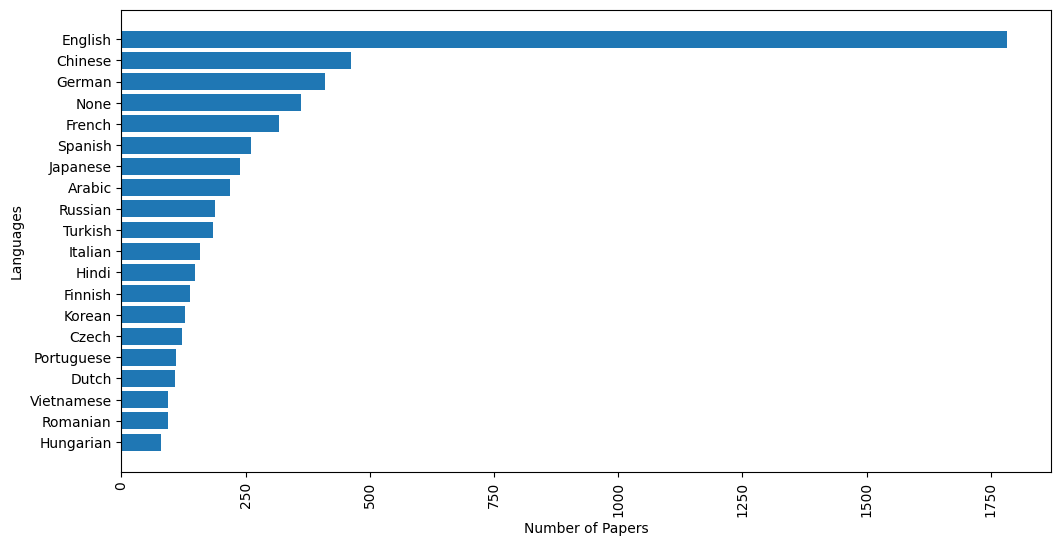

In [145]:
# Plot the most common languages
most_common = freq.most_common(20)
languages, counts = zip(*most_common)
plt.figure(figsize=(12, 6))
plt.barh(languages, counts)
plt.xticks(rotation=90)
plt.ylabel('Languages')
plt.xlabel('Number of Papers')
plt.gca().invert_yaxis()
plt.show()  


## Evaluation papers

- Papers over the years
- LLM: languages, motivation
- github / usable github


In [1]:
import importlib
import llm_filter
import pandas as pd
import paper_dataset
import tqdm
import iso639
import json
tqdm.tqdm.pandas()

/home/vico/personal_work_ms/TokSurvey/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


INFO 09-29 15:32:57 [__init__.py:220] No platform detected, vLLM is running on UnspecifiedPlatform
WARNING 09-29 15:32:59 [_custom_ops.py:20] Failed to import from vllm._C with ImportError('libcuda.so.1: cannot open shared object file: No such file or directory')


In [2]:
evaluation = pd.read_json('data/selected_tokenization_papers.jsonl', lines=True)
evaluation = evaluation[(evaluation['exclude'] == False) & (evaluation['evaluation'] == True)]
evaluation.shape

(173, 21)

In [ ]:
def exclusive_english(item):
    md = paper_dataset.get_markdown(item['pdf_url'])
    title = item['title'] if item['title'] is not None else ''
    answer = llm_filter.judge(llm_filter.SYSTEM_PROMPT_LANGUAGE, llm_filter.USER_PROMPT_LANGUAGE_EN, {'title': title, 'content': md}, local=True)
    return answer.lower().strip().startswith("yes")

def languages(item):
    md = paper_dataset.get_markdown(item['pdf_url'])
    title = item['title'] if item['title'] is not None else ''
    answer = llm_filter.judge(llm_filter.SYSTEM_PROMPT_LANGUAGE, llm_filter.USER_PROMPT_LANGUAGE_MULTILINGUAL, {'title': title, 'content': md}, local=True, max_tokens=1024)
    langs = llm_filter.extract_languages(answer)
    return langs, answer

In [2]:
# evaluation['exclusive_english'] = evaluation.progress_apply(exclusive_english, axis=1)
# all_answers = []
# all_langs = []
# for item in tqdm.tqdm(evaluation.iloc):
#     codes, answer = languages(item)
#     all_answers.append(answer)
#     all_langs.append(codes)
# with open('evaluation_language_answer.json', 'wt') as f:
#     json.dump(all_answers, f)

# evaluation['languages'] = all_langs
# evaluation.to_json('data/evaluation_papers.jsonl', orient='records', lines=True)
evaluation = pd.read_json('data/evaluation_papers.jsonl', lines=True)

## Add the other fields

- Based on BPE/Unigram/WordPiece/PIXEL/Tokenizer-free/Other
- Units: subword/morphemes/characters/bytes/pixels/other (x)
- Evaluation metrics (x)
- Multilingual (derived)
- Languages (x)
- Motivation 